## Bipartite Graphs Generator

Generated 200 graphs and saved them to ./../data/graphs/200graph_bipartite_16c.g6
Graph 1 properties:
  density: 0.25833333333333336
  diameter: 4
  clustering: 0.0
  max_degree: 5
  max_clique: 2
  is_bipartite: True

Graph 2 properties:
  density: 0.30833333333333335
  diameter: 4
  clustering: 0.0
  max_degree: 6
  max_clique: 2
  is_bipartite: True

Graph 3 properties:
  density: 0.2916666666666667
  diameter: 4
  clustering: 0.0
  max_degree: 5
  max_clique: 2
  is_bipartite: True

Graph 4 properties:
  density: 0.3
  diameter: 4
  clustering: 0.0
  max_degree: 6
  max_clique: 2
  is_bipartite: True

Graph 5 properties:
  density: 0.275
  diameter: 4
  clustering: 0.0
  max_degree: 6
  max_clique: 2
  is_bipartite: True



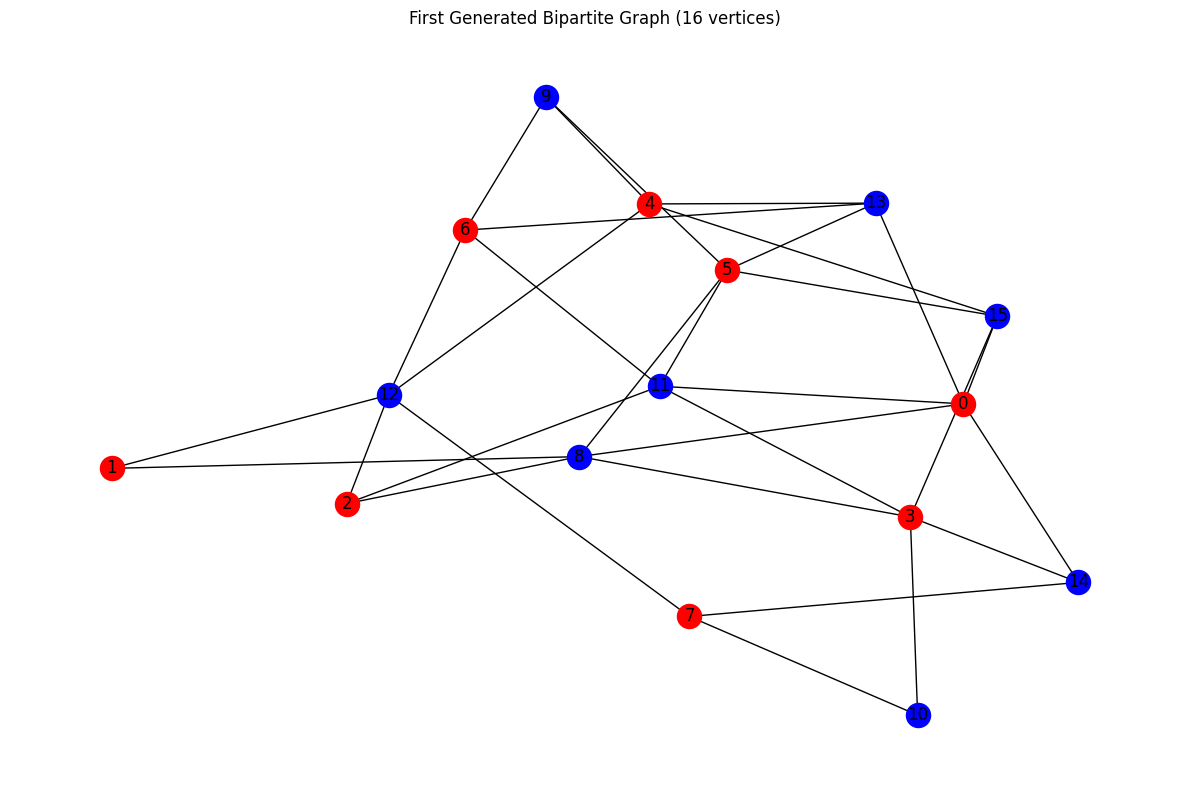

In [3]:
import networkx as nx
import random
import matplotlib.pyplot as plt

def generate_bipartite_graph(n1, n2, target_props):
    G = nx.Graph()
    G.add_nodes_from(range(n1), bipartite=0)
    G.add_nodes_from(range(n1, n1+n2), bipartite=1)
    
    max_edges = n1 * n2
    target_edges = int(target_props['density_max'] * max_edges)
    
    # Generate edges
    for i in range(n1):
        for j in range(n1, n1+n2):
            if random.random() < target_props['density_max']:
                G.add_edge(i, j)
    
    # Iterative refinement with more randomness
    for _ in range(200):  # Increased refinement attempts
        props = calculate_properties(G)
        
        if random.random() < 0.5:  # Randomly choose to add or remove edges
            if props['density'] < target_props['density_max']:
                i = random.randint(0, n1-1)
                j = random.randint(n1, n1+n2-1)
                if not G.has_edge(i, j):
                    G.add_edge(i, j)
            else:
                if G.number_of_edges() > 0:
                    G.remove_edge(*random.choice(list(G.edges())))
        else:
            if props['max_degree'] > target_props['max_degree_limit']:
                node = max(G.degree, key=lambda x: x[1])[0]
                G.remove_edge(node, random.choice(list(G.neighbors(node))))
            elif props['max_degree'] < target_props['max_degree_limit'] * 0.8:
                node = min(G.degree, key=lambda x: x[1])[0]
                other_partition = range(n1, n1+n2) if node < n1 else range(n1)
                possible_edges = [(node, j) for j in other_partition if not G.has_edge(node, j)]
                if possible_edges:
                    G.add_edge(*random.choice(possible_edges))
        
        # Occasionally allow for temporary violations to explore more diverse structures
        if random.random() < 0.1:
            if random.random() < 0.5:
                G.add_edge(random.randint(0, n1-1), random.randint(n1, n1+n2-1))
            else:
                if G.number_of_edges() > 0:
                    G.remove_edge(*random.choice(list(G.edges())))
    
    return G

def calculate_properties(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    density = m / (n * (n-1) / 2)  # Corrected density calculation for bipartite graphs
    try:
        diameter = nx.diameter(G)
    except:
        diameter = 0
    clustering = nx.average_clustering(G)
    max_degree = max(dict(G.degree()).values())
    max_clique = len(max(nx.find_cliques(G), key=len))
    
    return {
        'density': density,
        'diameter': diameter,
        'clustering': clustering,
        'max_degree': max_degree,
        'max_clique': max_clique,
        'is_bipartite': nx.is_bipartite(G)
    }

def graph_to_tuple(G):
    return tuple(sorted(G.edges()))

n_qubits = 4
n_vertices = 2**n_qubits
num_graphs = 200

type = 'bipartite'

n1, n2 = n_vertices // 2, n_vertices // 2
# output_file = f"./../data/graphs/{type}_graph{n_vertices}c.g6"
# output_file = f"./../data/graphs/wingraph{n_vertices}c.g6"
output_file = f"./../data/graphs/{num_graphs}graph_{type}_{n_vertices}c.g6"

target_props = {
    'density_max': random.uniform(0.2, 0.7),
    'diameter_min': random.uniform(3, 5),
    'clustering_max': 0.37,
    'max_degree_limit': random.uniform(4, 10),
    'max_clique_limit': 2,
    'is_bipartite': True
}

# target_props = {
#     'density_max': 1,
#     'diameter_min': 10,
#     'clustering_max': 5,
#     'max_degree_limit': 10,
#     'max_clique_limit': 10,
#     'is_bipartite': True
# }


generated_graphs = []
unique_graphs = set()

attempts = 0
max_attempts = 1000

while len(generated_graphs) < num_graphs and attempts < max_attempts:
    G = generate_bipartite_graph(n1, n2, target_props)
    graph_tuple = graph_to_tuple(G)
    
    if graph_tuple not in unique_graphs:
        unique_graphs.add(graph_tuple)
        props = calculate_properties(G)
        generated_graphs.append((G, props))
    
    attempts += 1

if attempts >= max_attempts:
    print(f"Warning: Could only generate {len(generated_graphs)} unique graphs after {max_attempts} attempts.")

# Write graphs to file
with open(output_file, 'w') as f:
    for G, props in generated_graphs:
        graph6_string = nx.to_graph6_bytes(G, header=False).decode().strip()
        f.write(f"{graph6_string}\n")

print(f"Generated {len(generated_graphs)} graphs and saved them to {output_file}")

# Print properties of the first 5 graphs
for i, (G, props) in enumerate(generated_graphs[:5]):
    print(f"Graph {i+1} properties:")
    for key, value in props.items():
        print(f"  {key}: {value}")
    print()

# Visualize the first graph
if generated_graphs:
    G, _ = generated_graphs[0]
    pos = nx.spring_layout(G)
    
    # Separate the nodes into the two partitions
    left_nodes = [node for node, data in G.nodes(data=True) if data['bipartite'] == 0]
    right_nodes = [node for node, data in G.nodes(data=True) if data['bipartite'] == 1]
    
    # Draw the graph
    plt.figure(figsize=(12, 8))
    nx.draw_networkx_nodes(G, pos, nodelist=left_nodes, node_color='r', node_size=300)
    nx.draw_networkx_nodes(G, pos, nodelist=right_nodes, node_color='b', node_size=300)
    nx.draw_networkx_edges(G, pos)
    nx.draw_networkx_labels(G, pos)
    
    plt.title(f"First Generated Bipartite Graph ({n_vertices} vertices)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No graphs were generated.")

In [4]:
# Print properties of the first 5 graphs
for i, (G, props) in enumerate(generated_graphs[:]):
    print(f"Graph {i+1} properties:")
    for key, value in props.items():
        print(f"  {key}: {value}")
    print()

Graph 1 properties:
  density: 0.25833333333333336
  diameter: 4
  clustering: 0.0
  max_degree: 5
  max_clique: 2
  is_bipartite: True

Graph 2 properties:
  density: 0.30833333333333335
  diameter: 4
  clustering: 0.0
  max_degree: 6
  max_clique: 2
  is_bipartite: True

Graph 3 properties:
  density: 0.2916666666666667
  diameter: 4
  clustering: 0.0
  max_degree: 5
  max_clique: 2
  is_bipartite: True

Graph 4 properties:
  density: 0.3
  diameter: 4
  clustering: 0.0
  max_degree: 6
  max_clique: 2
  is_bipartite: True

Graph 5 properties:
  density: 0.275
  diameter: 4
  clustering: 0.0
  max_degree: 6
  max_clique: 2
  is_bipartite: True

Graph 6 properties:
  density: 0.3
  diameter: 4
  clustering: 0.0
  max_degree: 5
  max_clique: 2
  is_bipartite: True

Graph 7 properties:
  density: 0.275
  diameter: 4
  clustering: 0.0
  max_degree: 5
  max_clique: 2
  is_bipartite: True

Graph 8 properties:
  density: 0.2916666666666667
  diameter: 4
  clustering: 0.0
  max_degree: 6
  ma

## Non-Bipartite Graphs Generator

In [1]:
import networkx as nx
import random
import matplotlib.pyplot as plt
from collections import defaultdict
import itertools
import numpy as np
import warnings

def generate_snake_like_path(n_vertices, is_bipartite):
    """Generate a very long path-like structure with high diameter."""
    G = nx.Graph()
    G.add_nodes_from(range(n_vertices))
    
    if is_bipartite:
        # Create a zigzag path that maintains bipartite property
        n1 = n_vertices // 2
        for i in range(n_vertices):
            G.nodes[i]['bipartite'] = 0 if i < n1 else 1
            
        # Create a snake-like path between partitions
        current_left = 0
        current_right = n1
        path_nodes = []
        
        while current_left < n1 and current_right < n_vertices:
            path_nodes.extend([current_left, current_right])
            current_left += 1
            current_right += 1
            
        # Add edges along the path
        for i in range(len(path_nodes)-1):
            G.add_edge(path_nodes[i], path_nodes[i+1])
            
    else:
        # For non-bipartite, create a winding path
        positions = []
        width = int(np.sqrt(n_vertices))
        for i in range(n_vertices):
            row = i // width
            col = i % width if row % 2 == 0 else width - 1 - (i % width)
            positions.append((row, col))
            
        # Sort nodes by their position to create a winding path
        nodes_order = sorted(range(n_vertices), key=lambda x: positions[x])
        
        # Create path edges
        for i in range(len(nodes_order)-1):
            G.add_edge(nodes_order[i], nodes_order[i+1])
    
    return G

def generate_high_diameter_graph(n_vertices, target_density, is_bipartite):
    """Generate a graph with high diameter while maintaining target density."""
    # Start with a snake-like path
    G = generate_snake_like_path(n_vertices, is_bipartite)
    
    # Calculate target number of edges
    if is_bipartite:
        n1 = n_vertices // 2
        n2 = n_vertices - n1
        max_edges = n1 * n2
    else:
        max_edges = (n_vertices * (n_vertices - 1)) // 2
    
    target_edges = int(target_density * max_edges)
    current_edges = G.number_of_edges()
    
    if current_edges < target_edges:
        # Add remaining edges while trying to maintain high diameter
        possible_edges = []
        for i, j in itertools.combinations(range(n_vertices), 2):
            if not G.has_edge(i, j):
                if is_bipartite:
                    if G.nodes[i]['bipartite'] != G.nodes[j]['bipartite']:
                        possible_edges.append((i, j))
                else:
                    possible_edges.append((i, j))
        
        # Calculate path lengths between potential edge endpoints
        path_lengths = {}
        for i, j in possible_edges:
            try:
                path_lengths[(i, j)] = nx.shortest_path_length(G, i, j)
            except nx.NetworkXNoPath:
                path_lengths[(i, j)] = float('inf')
        
        # Sort edges by path length (prefer adding edges between nodes that are already far apart)
        sorted_edges = sorted(possible_edges, key=lambda e: (-path_lengths[e], random.random()))
        
        # Add edges, but with decreasing probability as we add more
        edges_to_add = []
        current_path_lengths = list(path_lengths.values())
        current_diameter = max(x for x in current_path_lengths if x != float('inf'))
        
        for edge in sorted_edges:
            if len(edges_to_add) + current_edges >= target_edges:
                break
                
            # Probability of adding edge decreases as we get closer to target
            if random.random() < (path_lengths[edge] / current_diameter):
                edges_to_add.append(edge)
                
                # Update path lengths if we add this edge
                path_lengths[edge] = 1
                current_diameter = max(x for x in path_lengths.values() if x != float('inf'))
        
        G.add_edges_from(edges_to_add)
    
    return G

def calculate_density(G, is_bipartite):
    """Calculate the correct density based on graph type."""
    n = G.number_of_nodes()
    m = G.number_of_edges()
    
    if is_bipartite:
        # For bipartite graphs, density is edges / (n1 * n2)
        n1 = n // 2
        n2 = n - n1
        max_edges = n1 * n2
    else:
        # For non-bipartite graphs, density is edges / (n * (n-1)/2)
        max_edges = (n * (n - 1)) // 2
    
    return m / max_edges

def generate_diverse_graph(n_vertices, force_bipartite=None, target_density=None):
    """Generate a graph with target properties."""
    is_bipartite = force_bipartite if force_bipartite is not None else random.choice([True, False])
    
    if target_density is None:
        target_density = random.random()
    
    # For sparse graphs, use high diameter generation
    if target_density < 0.3:
        G = generate_high_diameter_graph(n_vertices, target_density, is_bipartite)
    else:
        # For denser graphs, use regular generation
        if is_bipartite:
            G = generate_bipartite_graph(n_vertices, target_density)
        else:
            G = generate_non_bipartite_graph(n_vertices, target_density)
    
    return G

def generate_bipartite_graph(n_vertices, target_density):
    """Generate a bipartite graph with specified density."""
    n1 = n_vertices // 2
    n2 = n_vertices - n1
    G = nx.Graph()
    G.add_nodes_from(range(n1), bipartite=0)
    G.add_nodes_from(range(n1, n_vertices), bipartite=1)
    
    max_possible_edges = n1 * n2
    target_edges = int(target_density * max_possible_edges)
    
    # Generate all possible edges and randomly select the target number
    possible_edges = [(i, j) for i in range(n1) for j in range(n1, n_vertices)]
    random.shuffle(possible_edges)
    edges_to_add = possible_edges[:target_edges]
    G.add_edges_from(edges_to_add)
    
    # Ensure connectivity
    if not nx.is_connected(G):
        components = list(nx.connected_components(G))
        for i in range(len(components) - 1):
            comp1_left = [n for n in components[i] if n < n1]
            comp1_right = [n for n in components[i] if n >= n1]
            comp2_left = [n for n in components[i+1] if n < n1]
            comp2_right = [n for n in components[i+1] if n >= n1]
            
            if comp1_left and comp2_right:
                G.add_edge(random.choice(comp1_left), random.choice(comp2_right))
            elif comp1_right and comp2_left:
                G.add_edge(random.choice(comp2_left), random.choice(comp1_right))
    
    return G

def generate_non_bipartite_graph(n_vertices, target_density):
    """Generate a non-bipartite graph with specified density."""
    max_possible_edges = (n_vertices * (n_vertices - 1)) // 2
    target_edges = int(target_density * max_possible_edges)
    
    if target_density < 0.1:
        # For very sparse graphs, start with a cycle or path
        if random.random() < 0.5:
            G = nx.cycle_graph(n_vertices)
        else:
            G = nx.path_graph(n_vertices)
    else:
        G = nx.Graph()
        G.add_nodes_from(range(n_vertices))
    
    current_edges = G.number_of_edges()
    
    if current_edges < target_edges:
        possible_edges = list(itertools.combinations(range(n_vertices), 2))
        possible_edges = [e for e in possible_edges if not G.has_edge(e[0], e[1])]
        random.shuffle(possible_edges)
        edges_to_add = possible_edges[:target_edges - current_edges]
        G.add_edges_from(edges_to_add)
    
    return G

def calculate_properties(G):
    """Calculate various graph properties with proper error handling."""
    props = {
        'nodes': G.number_of_nodes(),
        'edges': G.number_of_edges(),
        'density': calculate_density(G, nx.is_bipartite(G)),
        'clustering': nx.average_clustering(G),
        'max_degree': max(dict(G.degree()).values()),
        'min_degree': min(dict(G.degree()).values()),
        'avg_degree': sum(dict(G.degree()).values()) / G.number_of_nodes(),
        'is_connected': nx.is_connected(G),
        'is_bipartite': nx.is_bipartite(G)
    }
    
    # Calculate diameter
    try:
        props['diameter'] = nx.diameter(G)
    except (nx.NetworkXError, nx.NetworkXNoPath):
        props['diameter'] = float('inf')
    
    # Calculate assortativity with warning suppression
    try:
        with warnings.catch_warnings():
            warnings.filterwarnings('ignore', category=RuntimeWarning)
            assortativity = nx.degree_assortativity_coefficient(G)
            props['assortativity'] = 0.0 if np.isnan(assortativity) else assortativity
    except:
        props['assortativity'] = 0.0
    
    return props

def generate_graphs(n_vertices, num_graphs, output_file):
    """Generate diverse graphs with even density distribution."""
    generated_graphs = []
    unique_graphs = set()
    attempts = 0
    max_attempts = num_graphs * 10
    
    # Separate bins for bipartite and non-bipartite graphs
    num_bins = 10
    bipartite_bins = [[] for _ in range(num_bins)]
    non_bipartite_bins = [[] for _ in range(num_bins)]
    target_per_type_bin = num_graphs // (2 * num_bins)  # Half for each type
    
    print(f"Generating {num_graphs} diverse graphs...")
    
    while len(generated_graphs) < num_graphs and attempts < max_attempts:
        # Determine target type and density
        current_bipartite_counts = [len(bin) for bin in bipartite_bins]
        current_non_bipartite_counts = [len(bin) for bin in non_bipartite_bins]
        
        # Check if either type is full
        bipartite_full = all(count >= target_per_type_bin for count in current_bipartite_counts)
        non_bipartite_full = all(count >= target_per_type_bin for count in current_non_bipartite_counts)
        
        if bipartite_full and not non_bipartite_full:
            force_bipartite = False
        elif non_bipartite_full and not bipartite_full:
            force_bipartite = True
        else:
            force_bipartite = random.choice([True, False])
        
        # Choose target density from underfilled bins
        if force_bipartite:
            underfilled_bins = [i for i, count in enumerate(current_bipartite_counts) 
                              if count < target_per_type_bin]
        else:
            underfilled_bins = [i for i, count in enumerate(current_non_bipartite_counts) 
                              if count < target_per_type_bin]
        
        if underfilled_bins:
            target_bin = random.choice(underfilled_bins)
            # Ensure even distribution within bin
            target_density = (target_bin + random.random()) / num_bins
        else:
            target_density = random.random()
            
        G = generate_diverse_graph(n_vertices, force_bipartite, target_density)
        graph_tuple = tuple(sorted(G.edges()))
        
        if graph_tuple not in unique_graphs and nx.is_connected(G):
            unique_graphs.add(graph_tuple)
            props = calculate_properties(G)
            generated_graphs.append((G, props))
            
            # Add to appropriate bin
            density_bin = min(num_bins - 1, int(props['density'] * num_bins))
            if props['is_bipartite']:
                bipartite_bins[density_bin].append(props)
            else:
                non_bipartite_bins[density_bin].append(props)
            
            if len(generated_graphs) % 100 == 0:
                print(f"Generated {len(generated_graphs)} graphs...")
                print("Bipartite densities:", [len(bin) for bin in bipartite_bins])
                print("Non-bipartite densities:", [len(bin) for bin in non_bipartite_bins])
        
        attempts += 1
    
    # Write graphs to file
    with open(output_file, 'w') as f:
        for G, _ in generated_graphs:
            graph6_string = nx.to_graph6_bytes(G, header=False).decode().strip()
            f.write(f"{graph6_string}\n")
    
    print(f"\nGenerated {len(generated_graphs)} graphs and saved them to {output_file}")
    
    # Print detailed density distribution
    print("\nBipartite graph density distribution:")
    for i, bin in enumerate(bipartite_bins):
        range_start = i / num_bins
        range_end = (i + 1) / num_bins
        print(f"Density {range_start:.1f}-{range_end:.1f}: {len(bin)} graphs")
    
    print("\nNon-bipartite graph density distribution:")
    for i, bin in enumerate(non_bipartite_bins):
        range_start = i / num_bins
        range_end = (i + 1) / num_bins
        print(f"Density {range_start:.1f}-{range_end:.1f}: {len(bin)} graphs")
    
    # Print overall property ranges
    print("\nProperty ranges across all generated graphs:")
    all_props = [props for _, props in generated_graphs]
    
    for key in all_props[0].keys():
        if key in ['is_connected', 'is_bipartite']:
            continue
        values = [props[key] for props in all_props]
        print(f"{key}:")
        print(f"  Min: {min(values):.2f}")
        print(f"  Max: {max(values):.2f}")
        print(f"  Avg: {sum(values)/len(values):.2f}")


# Main execution
if __name__ == "__main__":
    n_qubits = 3
    n_vertices = 2**n_qubits  
    num_graphs = 100

    type = '50-50'

    output_file = f"./../data/graphs/{num_graphs}graph_{type}_{n_vertices}c.g6"
    generate_graphs(n_vertices, num_graphs, output_file)

Generating 100 diverse graphs...
Generated 100 graphs...
Bipartite densities: [0, 0, 0, 0, 25, 11, 8, 5, 8, 5]
Non-bipartite densities: [0, 0, 0, 5, 5, 5, 5, 5, 8, 5]

Generated 100 graphs and saved them to ./../data/graphs/100graph_50-50_8c.g6

Bipartite graph density distribution:
Density 0.0-0.1: 0 graphs
Density 0.1-0.2: 0 graphs
Density 0.2-0.3: 0 graphs
Density 0.3-0.4: 0 graphs
Density 0.4-0.5: 25 graphs
Density 0.5-0.6: 11 graphs
Density 0.6-0.7: 8 graphs
Density 0.7-0.8: 5 graphs
Density 0.8-0.9: 8 graphs
Density 0.9-1.0: 5 graphs

Non-bipartite graph density distribution:
Density 0.0-0.1: 0 graphs
Density 0.1-0.2: 0 graphs
Density 0.2-0.3: 0 graphs
Density 0.3-0.4: 5 graphs
Density 0.4-0.5: 5 graphs
Density 0.5-0.6: 5 graphs
Density 0.6-0.7: 5 graphs
Density 0.7-0.8: 5 graphs
Density 0.8-0.9: 8 graphs
Density 0.9-1.0: 5 graphs

Property ranges across all generated graphs:
nodes:
  Min: 8.00
  Max: 8.00
  Avg: 8.00
edges:
  Min: 7.00
  Max: 27.00
  Avg: 13.07
density:
  Min: 0

## Win to Pauli


In [2]:
import sys
sys.path.append(f"./../")
import networkx as nx
import random
from src.misc import *

def generate_winning_graph(n1):
    """Generate a graph that should win in Matching vs Pauli comparison."""
    # Calculate n2 based on requirement
    n2 = 16 - n1
    
    # Create complete bipartite graph
    G = nx.complete_bipartite_graph(n1, n2)
    
    # Calculate initial number of edges
    initial_edges = n1 * n2
    initial_max_degree = max(dict(G.degree()).values())
    print(f"Initial max degree: {initial_max_degree}")
    
    deleted_edges = set()
    
    # Keep deleting edges until we either reach target density or can't delete more
    while True:
        # Find vertex with highest degree
        degrees = dict(G.degree())
        max_degree = max(degrees.values())
        
        # Check if we've reached acceptable max degree and density
        density = calculate_edge_density(G)
        if max_degree <= 9 and density <= 0.46 and nx.is_connected(G):
            break
            
        high_degree_vertices = [v for v, d in degrees.items() if d == max_degree]
        
        # Randomly select one of the high degree vertices
        vertex = random.choice(high_degree_vertices)
        
        # Get all edges connected to this vertex
        possible_edges = list(G.edges(vertex))
        
        if not possible_edges:
            continue
            
        # Randomly select an edge to delete
        edge = random.choice(possible_edges)
        
        # Temporarily remove the edge
        G.remove_edge(*edge)
        
        # Check if graph is still connected
        if not nx.is_connected(G):
            # If not connected, put the edge back
            G.add_edge(*edge)
            continue
            
        deleted_edges.add(edge)
    
    # Final check
    density = calculate_edge_density(G)
    final_max_degree = max(dict(G.degree()).values())
    
    if not nx.is_connected(G) or density > 0.46 or final_max_degree > 9:
        return None
    
    print(f"Final max degree: {final_max_degree}, Density: {density:.3f}")
    return G, final_max_degree

# Configuration
n_qubits = 4  # Total number of qubits for vertex count
n_vertices = 2**n_qubits
n_graphs = 200  # Number of graphs to generate
n1_values = [6, 7, 8]  # Possible values for n1
graphs_per_n1 = n_graphs // len(n1_values)

# Output file
output_file = f"./../data/graphs/{n_graphs}graph_win_Pauli_{n_vertices}c.g6"

# Generate graphs
generated_graphs = []
max_degrees = []
for n1 in n1_values:
    count = 0
    attempts = 0
    max_attempts = 1000
    
    print(f"\nGenerating graphs for n1={n1}...")
    n1_max_degrees = []  # Store max degrees for this n1
    
    while count < graphs_per_n1 and attempts < max_attempts:
        result = generate_winning_graph(n1)
        if result is not None:
            G, max_degree = result
            # Verify the graph meets our criteria
            if max_degree <= 9:  # Double check max degree
                generated_graphs.append(G)
                max_degrees.append(max_degree)
                n1_max_degrees.append(max_degree)
                count += 1
                density = calculate_edge_density(G)
                print(f"Generated graph {count}/{graphs_per_n1} for n1={n1} (density={density:.3f}, max_degree={max_degree})")
        attempts += 1
    
    if count < graphs_per_n1:
        print(f"Warning: Could only generate {count} graphs for n1={n1} after {max_attempts} attempts")
    
    # Print statistics for this n1
    if n1_max_degrees:
        print(f"\nMax degree statistics for n1={n1}:")
        print(f"Range: {min(n1_max_degrees)} - {max(n1_max_degrees)}")
        print(f"Average: {sum(n1_max_degrees)/len(n1_max_degrees):.2f}")

# Save graphs to file
print(f"\nSaving {len(generated_graphs)} graphs to {output_file}")
with open(output_file, 'w') as f:
    for G in generated_graphs:
        graph6_string = nx.to_graph6_bytes(G, header=False).decode().strip()
        f.write(f"{graph6_string}\n")

# Print final statistics
print("\nDataset Statistics:")
print(f"Total graphs generated: {len(generated_graphs)}")

# Calculate density statistics
densities = [calculate_edge_density(G) for G in generated_graphs]
print(f"Density range: {min(densities):.3f} - {max(densities):.3f}")
print(f"Average density: {sum(densities)/len(densities):.3f}")

# Print max degree statistics
print("\nMax Degree Statistics (all graphs):")
print(f"Range: {min(max_degrees)} - {max(max_degrees)}")
print(f"Average: {sum(max_degrees)/len(max_degrees):.2f}")

# Calculate bipartite statistics
bipartite_count = sum(1 for G in generated_graphs if is_bipartite(G))
print("\nBipartiteness Check:")
print(f"Bipartite graphs: {bipartite_count} ({(bipartite_count/len(generated_graphs))*100:.1f}%)")
print(f"Non-bipartite graphs: {len(generated_graphs) - bipartite_count} ({((len(generated_graphs) - bipartite_count)/len(generated_graphs))*100:.1f}%)")

# Print bipartite graph statistics
if bipartite_count > 0:
    bipartite_densities = [calculate_edge_density(G) for G in generated_graphs if is_bipartite(G)]
    print("\nBipartite Graphs Statistics:")
    print(f"Density range: {min(bipartite_densities):.3f} - {max(bipartite_densities):.3f}")
    print(f"Average density: {sum(bipartite_densities)/len(bipartite_densities):.3f}")


Generating graphs for n1=6...
Initial max degree: 10
Final max degree: 9, Density: 0.450
Generated graph 1/66 for n1=6 (density=0.450, max_degree=9)
Initial max degree: 10
Final max degree: 9, Density: 0.450
Generated graph 2/66 for n1=6 (density=0.450, max_degree=9)
Initial max degree: 10
Final max degree: 9, Density: 0.450
Generated graph 3/66 for n1=6 (density=0.450, max_degree=9)
Initial max degree: 10
Final max degree: 9, Density: 0.450
Generated graph 4/66 for n1=6 (density=0.450, max_degree=9)
Initial max degree: 10
Final max degree: 9, Density: 0.450
Generated graph 5/66 for n1=6 (density=0.450, max_degree=9)
Initial max degree: 10
Final max degree: 9, Density: 0.450
Generated graph 6/66 for n1=6 (density=0.450, max_degree=9)
Initial max degree: 10
Final max degree: 9, Density: 0.450
Generated graph 7/66 for n1=6 (density=0.450, max_degree=9)
Initial max degree: 10
Final max degree: 9, Density: 0.450
Generated graph 8/66 for n1=6 (density=0.450, max_degree=9)
Initial max degre

## Lose to Pauli

In [1]:
import sys
sys.path.append(f"./../")
import networkx as nx
import random
from src.misc import *

def generate_losing_graph(n_vertices):
    """Generate a high density random graph that should lose to Pauli."""
    # Create a random graph with high density (between 0.7 and 0.9)
    density = random.uniform(0.7, 0.9)
    prob = density  # For Erdos-Renyi model, probability equals desired density
    
    # Generate random graph with given probability
    G = nx.erdos_renyi_graph(n_vertices, prob)
    
    # Ensure connectivity
    while not nx.is_connected(G):
        G = nx.erdos_renyi_graph(n_vertices, prob)
    
    return G

# Configuration
n_qubits = 4  # Total number of qubits for vertex count
n_vertices = 2**n_qubits
n_graphs = 200  # Number of graphs to generate

# Output file
output_file = f"./../data/graphs/{n_graphs}graph_losing_{n_vertices}c.g6"

# Generate graphs
generated_graphs = []
attempts = 0
max_attempts = n_graphs * 2  # Allow some extra attempts

print(f"Generating {n_graphs} high-density graphs...")
while len(generated_graphs) < n_graphs and attempts < max_attempts:
    G = generate_losing_graph(n_vertices)
    
    # Verify the graph meets our criteria
    density = calculate_edge_density(G)
    if nx.is_connected(G):
        generated_graphs.append(G)
        if len(generated_graphs) % 10 == 0:  # Print progress every 10 graphs
            print(f"Generated graph {len(generated_graphs)}/{n_graphs} (density={density:.3f})")
    
    attempts += 1

# Save graphs to file
print(f"\nSaving {len(generated_graphs)} graphs to {output_file}")
with open(output_file, 'w') as f:
    for G in generated_graphs:
        graph6_string = nx.to_graph6_bytes(G, header=False).decode().strip()
        f.write(f"{graph6_string}\n")

# Print statistics for verification
print("\nDataset Statistics:")
print(f"Total graphs generated: {len(generated_graphs)}")

# Calculate density statistics
densities = [calculate_edge_density(G) for G in generated_graphs]
print(f"Density range: {min(densities):.3f} - {max(densities):.3f}")
print(f"Average density: {sum(densities)/len(densities):.3f}")

# Calculate bipartite statistics
bipartite_count = sum(1 for G in generated_graphs if is_bipartite(G))
print("\nBipartiteness Check:")
print(f"Bipartite graphs: {bipartite_count} ({(bipartite_count/len(generated_graphs))*100:.1f}%)")
print(f"Non-bipartite graphs: {len(generated_graphs) - bipartite_count} ({((len(generated_graphs) - bipartite_count)/len(generated_graphs))*100:.1f}%)")

Generating 200 high-density graphs...
Generated graph 10/200 (density=0.775)
Generated graph 20/200 (density=0.783)
Generated graph 30/200 (density=0.817)
Generated graph 40/200 (density=0.783)
Generated graph 50/200 (density=0.875)
Generated graph 60/200 (density=0.733)
Generated graph 70/200 (density=0.867)
Generated graph 80/200 (density=0.800)
Generated graph 90/200 (density=0.875)
Generated graph 100/200 (density=0.733)
Generated graph 110/200 (density=0.725)
Generated graph 120/200 (density=0.842)
Generated graph 130/200 (density=0.725)
Generated graph 140/200 (density=0.883)
Generated graph 150/200 (density=0.850)
Generated graph 160/200 (density=0.717)
Generated graph 170/200 (density=0.750)
Generated graph 180/200 (density=0.642)
Generated graph 190/200 (density=0.683)
Generated graph 200/200 (density=0.875)

Saving 200 graphs to ./../data/graphs/200graph_losing_16c.g6

Dataset Statistics:
Total graphs generated: 200
Density range: 0.642 - 0.917
Average density: 0.807

Biparti